# HydroSeason: Step-by-Step Example Application

Welcome to the step-by-step example tutorial for **HydroSeason**!

HydroSeason is a Python package for **source-agnostic hydrological-year detection** from monthly surface-water extent. It supports remote-sensing-first workflows, allowing you to detect wet/dry seasons and hydrological years from:
- Monthly water-extent CSV files (precomputed)
- Generic binary or canonical water-mask rasters (TIFs or Zarr cubes)
- STAC catalogs (e.g. WOfS on Digital Earth Australia)

This notebook walks you through a complete end-to-end workflow:
1. **Generating mock water-extent data** containing seasonal variation, cloud cover noise, and missing observations.
2. **Loading data** using the CSV loader (`load_extent_csv`).
3. **Detecting hydrological years** with search windows (`detect_hydrological_years`).
4. **Labelling individual months** as Wet/Dry (`label_hydrological_months`).
5. **Visualizing** results inline using matplotlib.
6. **Generating a gorgeous, interactive HTML summary report** (`generate_html_report`).

## 1. Imports and Setup

First, we import the required dependencies and HydroSeason modules. Make sure you have installed `hydroseason` and its extras (like raster support if working with rasters, though only core `pandas`/`numpy` are needed for this CSV/report path).

In [1]:
from __future__ import annotations

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hydroseason import (
    HydroYearConfig,
    detect_hydrological_years,
    label_hydrological_months,
    load_extent_csv,
    generate_html_report,
)

print("Imports successful!")

C:\Users\00101125\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\00101125\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Imports successful!


## 2. Generate Mock Water-Extent Data

To simulate a typical remote-sensing water-extent series, we generate 5 years of monthly data. The model represents water extent as a percentage of the Area of Interest (AOI):
- `extent_pct`: The percentage of pixels classified as water (0 to 100%).
- `invalid_pct`: The percentage of pixels that are invalid (due to cloud, shadow, or sensor gaps).

We inject:
- A strong wet/dry seasonal cycle peaking in February and troughing in August.
- A minor random noise factor.
- Some invalid cloud coverage (low invalid % generally, but with a couple of high-invalid months).
- A missing month (to demonstrate how HydroSeason checks for index completeness).

In [2]:
def create_mock_extent_data(start_date="2020-01-01", periods=60):
    # Generate month-start dates
    dates = pd.date_range(start_date, periods=periods, freq="MS")
    
    # Base seasonal pattern peaking in Feb (month 2) and bottoming in Aug (month 8)
    months = dates.month
    amplitude = 35.0 * np.cos(2 * np.pi * (months - 2) / 12) + 45.0
    
    # Add noise
    np.random.seed(42)
    noise = np.random.normal(0, 3.0, size=len(dates))
    extent_pct = np.clip(amplitude + noise, 0, 100)
    
    # Generate cloud cover (invalid_pct)
    invalid_pct = np.random.exponential(scale=3.0, size=len(dates))
    invalid_pct = np.clip(invalid_pct, 0, 100)
    
    # Inject a couple of heavily clouded months (e.g. 25% and 40% cloud)
    invalid_pct[12] = 25.0  # Jan 2021
    invalid_pct[28] = 40.0  # May 2022
    
    df = pd.DataFrame({
        "date": dates.strftime("%Y-%m-%d"),
        "extent_pct": np.round(extent_pct, 2),
        "invalid_pct": np.round(invalid_pct, 2)
    })
    
    return df

mock_df = create_mock_extent_data()

# Remove one month to simulate a gap (e.g., September 2023 at index 44)
mock_df = mock_df.drop(44).reset_index(drop=True)

# Save mock dataset to CSV
csv_path = Path("mock_monthly_extent.csv")
mock_df.to_csv(csv_path, index=False)
print(f"Mock data saved to {csv_path.resolve()}")
mock_df.head(10)

Mock data saved to D:\RLH\5.6\repos\hydroseason\notebooks\mock_monthly_extent.csv


,date,extent_pct,invalid_pct
0,2020-01-01,76.80,1.21
1,2020-02-01,79.59,0.20
2,2020-03-01,77.25,1.12
3,2020-04-01,67.07,1.18
4,2020-05-01,44.30,3.92
5,2020-06-01,26.80,3.04
6,2020-07-01,19.43,6.55
7,2020-08-01,12.30,1.92
8,2020-09-01,13.28,0.38
9,2020-10-01,29.13,3.75


## 3. Load Water-Extent Series

Using HydroSeason's `load_extent_csv` loader, we load the CSV. This returns a `pd.DataFrame` with a `pd.DatetimeIndex` on standard month-start boundaries.

> **Note:** If we try to run detection directly with missing months, HydroSeason will fail closed by default to prevent boundary shifts. Let's see how `load_extent_csv` handles this.

In [3]:
extent = load_extent_csv(csv_path, date_col="date", value_col="extent_pct")
print(f"Loaded series shape: {extent.shape}")
print(f"Index type: {type(extent.index)}")
extent.head()

Loaded series shape: (59, 2)
Index type: <class 'pandas.DatetimeIndex'>


,extent_pct,invalid_pct
date,,
2020-01-01,76.80,1.21
2020-02-01,79.59,0.20
2020-03-01,77.25,1.12
2020-04-01,67.07,1.18
2020-05-01,44.30,3.92


## 4. Run Hydrological Year Detection

Now we configure and run the core detection algorithm. The configuration class `HydroYearConfig` allows you to customize:
- `wet_start_month` & `wet_end_month`: Search window for the wet peak (e.g. November of year Y-1 to April of year Y).
- `dry_start_month` & `dry_end_month`: Search window for the dry trough (e.g. July to December of year Y).
- confidence thresholds (`low_confidence_ratio`, `medium_confidence_ratio`).

First, we'll demonstrate what happens if we attempt to detect hydrological years while a month is missing.

In [4]:
try:
    detect_hydrological_years(extent)
except ValueError as e:
    print(f"Expected safety validation error:\n{e}")

Expected safety validation error:
Invalid coverage exceeds max_invalid_pct or is unknown; use completed masks, quality-screen the series, or explicitly raise the threshold.


To handle missing months, we can either:
1. **Pass `missing_month_policy='ignore'`**: Forces the algorithm to proceed despite gaps (not recommended if gaps fall near wet/dry transitions).
2. **Gapfill the series**: Recommend running gapfilling (like WaterMask-TSFill) first. Since we are using CSV, we can also bypass it or raise `max_invalid_pct` if months are invalid.

Let's also look at the cloud cover safety threshold (`max_invalid_pct`). In our mock dataset, we injected months with 25% and 40% invalid pixels. The default validation rejects any series containing a month with $>20\%$ invalid pixels. Let's try to run with `missing_month_policy='ignore'` and see if the cloud cover check triggers.

In [5]:
try:
    detect_hydrological_years(extent, missing_month_policy="ignore")
except ValueError as e:
    print(f"Expected invalid coverage error:\n{e}")

Expected invalid coverage error:
Invalid coverage exceeds max_invalid_pct or is unknown; use completed masks, quality-screen the series, or explicitly raise the threshold.


Let's explicitly raise the cloud cover threshold to `max_invalid_pct=50.0` (meaning we permit up to 50% cloud cover in any given month before failing) and ignore missing months to successfully perform detection.

In [6]:
config = HydroYearConfig(
    wet_start_month=11, 
    wet_end_month=4, 
    dry_start_month=7, 
    dry_end_month=12
)

hydro_years = detect_hydrological_years(
    extent,
    config=config,
    missing_month_policy="ignore",
    max_invalid_pct=50.0
)

print(f"Successfully detected {len(hydro_years)} hydrological years:")
hydro_years

Successfully detected 5 hydrological years:


,hy_year,hy_start,hy_end,peak_month,peak_extent_pct,mid_dry_month,mid_extent_pct,end_dry_month,end_extent_pct,amplitude_pct,n_months_cycle,confidence,boundary_source
0,2020,2020-01-01,2020-08-01,2020-02-01,79.59,2020-05-01,44.30,2020-08-01,12.30,67.29,8,high,annual_window
1,2021,2020-09-01,2021-08-01,2021-01-01,76.04,2021-05-01,41.96,2021-08-01,5.76,70.28,12,high,annual_window
2,2022,2021-09-01,2022-07-01,2022-02-01,80.33,2022-05-01,43.20,2022-07-01,12.88,67.45,11,high,annual_window
3,2023,2022-08-01,2023-08-01,2023-01-01,75.94,2023-05-01,47.22,2023-08-01,9.10,66.84,13,high,annual_window
4,2024,2023-09-01,2024-09-01,2024-01-01,76.34,2024-05-01,42.97,2024-09-01,12.17,64.17,13,high,annual_window


### Column Explanation:
- `hy_year`: The detected hydrological year (e.g. 2021).
- `hy_start` / `hy_end`: The boundary month range of the hydrological year cycle.
- `peak_month` & `peak_extent_pct`: Target month and value of maximum surface-water extent.
- `end_dry_month` & `end_extent_pct`: Target month and value of minimum surface-water extent (max hydrological stress).
- `mid_dry_month` & `mid_extent_pct`: The month representing the midpoint of the dry phase.
- `amplitude_pct`: The difference between peak wet and end dry water extents (wet peak - dry end).
- `n_months_cycle`: Total months spanning the detected hydrological cycle.
- `confidence`: Quality assignment (`high`, `medium`, `low`) based on seasonal amplitude relative to the overall median.

## 5. Label Individual Months

We use `label_hydrological_months` to map every calendar month in our series to its corresponding hydrological year and season (`Wet` vs `Dry`).

In [7]:
labels = label_hydrological_months(extent.index, hydro_years)
labels.head(15)

,hy_year,season
date,,
2020-01-01,2020.0,Wet
2020-02-01,2020.0,Wet
2020-03-01,2020.0,Dry
2020-04-01,2020.0,Dry
2020-05-01,2020.0,Dry
2020-06-01,2020.0,Dry
2020-07-01,2020.0,Dry
2020-08-01,2020.0,Dry
2020-09-01,2021.0,Wet


## 6. Visualization

Let's plot the monthly water extent over time, shading the background blue during `Wet` seasons and orange during `Dry` seasons, and marking the detected peaks (green) and dry ends (red).

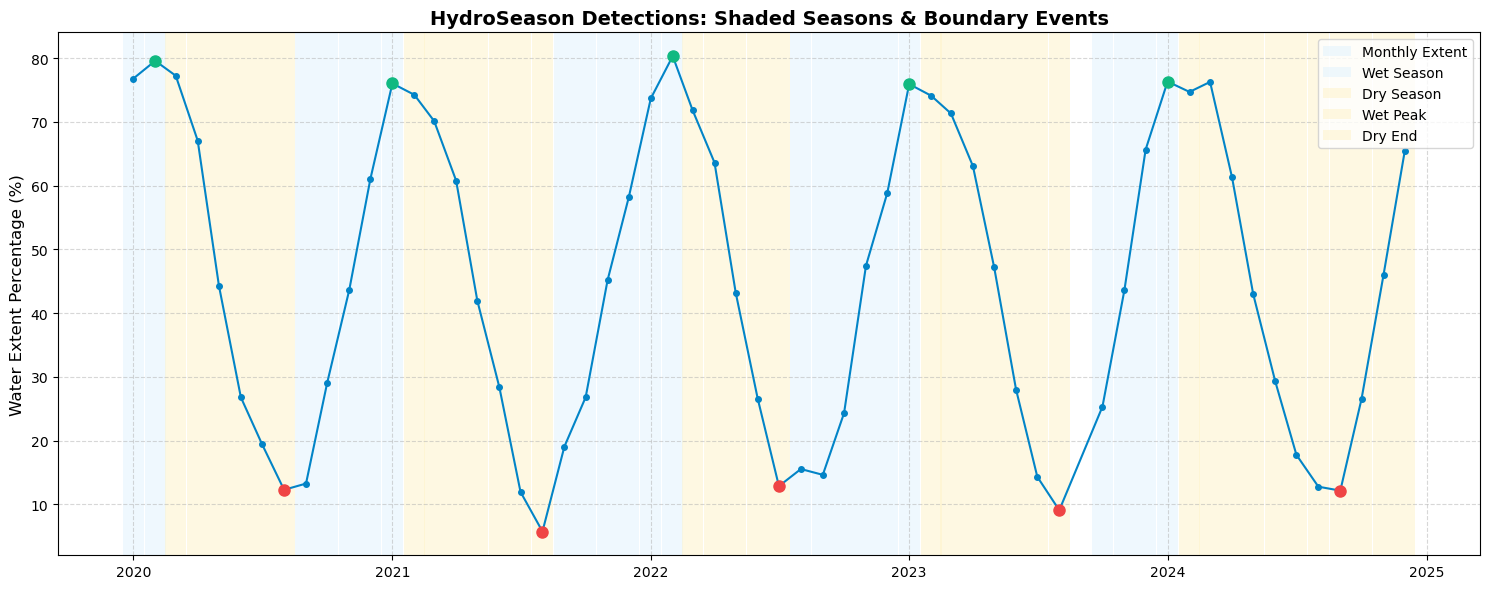

In [8]:
plt.figure(figsize=(15, 6))

# Shade seasons
for ts, row in labels.iterrows():
    color = "#e0f2fe" if row["season"] == "Wet" else "#fef3c7"
    plt.axvspan(ts - pd.Timedelta(days=15), ts + pd.Timedelta(days=15), color=color, alpha=0.5, linewidth=0)

# Plot monthly extent
plt.plot(extent.index, extent["extent_pct"], color="#0284c7", marker="o", markersize=4, label="Monthly Extent (%)")

# Highlight peaks and dry ends
for _, row in hydro_years.iterrows():
    plt.plot(pd.Timestamp(row["peak_month"]), row["peak_extent_pct"], marker="o", color="#10b981", markersize=8, zorder=5)
    plt.plot(pd.Timestamp(row["end_dry_month"]), row["end_extent_pct"], marker="o", color="#ef4444", markersize=8, zorder=5)

plt.title("HydroSeason Detections: Shaded Seasons & Boundary Events", fontsize=14, fontweight="bold")
plt.ylabel("Water Extent Percentage (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(["Monthly Extent", "Wet Season", "Dry Season", "Wet Peak", "Dry End"], loc="upper right")
plt.tight_layout()
plt.show()

## 7. Generate Interactive HTML Summary Report

Finally, we can export the entire analysis to a self-contained, interactive HTML summary report using `generate_html_report`. This file contains all details, interactive elements, filterable data grids, and a customized SVG-based interactive chart.

In [9]:
report_path = Path("hydroseason_analysis_report.html")
generate_html_report(
    extent=extent,
    hydro_years=hydro_years,
    output_path=report_path,
    title="HydroSeason Tutorial Analysis Report"
)

print(f"HTML Report successfully written to:\n{report_path.resolve()}")

HTML Report successfully written to:
D:\RLH\5.6\repos\hydroseason\notebooks\hydroseason_analysis_report.html


Double-click the generated file `hydroseason_analysis_report.html` in your file explorer to open it in any browser! It requires no active Python kernel or internet connection to display the interactive chart, expandable cards, and filterable data tables.